### Download and unzip the dataset

In [1]:
!wget "https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip?download=1" -O ravdess.zip
!unzip ravdess.zip -d data
!rm ravdess.zip

--2026-10-08 16:05:22--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.185.43.153, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘ravdess.zip’

ravdess.zip         100%[===================>] 198.81M  2.77MB/s    in 78s     

2026-10-08 16:06:40 (2.56 MB/s) - ‘ravdess.zip’ saved [208468073/208468073]

Archive:  ravdess.zip
   creating: data/Actor_01/
  inflating: data/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: data/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: data/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: data/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: data/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: data/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: data/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: data/Acto

### Install openSMILE

In [2]:
!pip install opensmile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 30.8 MB/s eta 0:00:00


### 1. Process the dataset with openSMILE using low-level descriptors AND functionals

In [3]:
import opensmile
from pathlib import Path

# LLDs
smile_lld = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors
)

# Functionals
smile_func = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals
)

data_path = Path('data')
data = []
labels = []
for f in data_path.rglob('*.wav'):
    data.append(f)
    labels.append(int(f.stem[7]))

print(labels[:10])

df_func = smile_func.process_files(data)
df_lld = smile_lld.process_files(data)

df_func['label'] = labels

[6, 2, 4, 5, 7, 8, 6, 6, 3, 7]


### Standard OpenSmile output - functionals

In [4]:
print(df_func.info())
df_func.head()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1440 entries, ('data/Actor_11/03-01-06-01-01-02-11.wav', Timedelta('0 days 00:00:00'), Timedelta('0 days 00:00:03.503499999')) to ('data/Actor_09/03-01-01-01-02-01-09.wav', Timedelta('0 days 00:00:00'), Timedelta('0 days 00:00:03.336666667'))
Data columns (total 89 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   F0semitoneFrom27.5Hz_sma3nz_amean               1440 non-null   float32
 1   F0semitoneFrom27.5Hz_sma3nz_stddevNorm          1440 non-null   float32
 2   F0semitoneFrom27.5Hz_sma3nz_percentile20.0      1440 non-null   float32
 3   F0semitoneFrom27.5Hz_sma3nz_percentile50.0      1440 non-null   float32
 4   F0semitoneFrom27.5Hz_sma3nz_percentile80.0      1440 non-null   float32
 5   F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2        1440 non-null   float32
 6   F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope     1440 

,,,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,label
file,start,end,,,,,,,,,,,,,,,,,,,,,
data/Actor_11/03-01-06-01-01-02-11.wav,0 days,0 days 00:00:03.503499999,28.241516,0.119524,26.598331,28.823990,30.901754,4.303423,226.643555,314.081757,26.191912,12.072890,...,0.010448,0.014132,3.151862,0.872093,0.426667,0.342377,0.522500,0.471242,-42.392647,6
data/Actor_11/03-01-02-02-02-01-11.wav,0 days,0 days 00:00:03.770437500,24.850216,0.252050,22.304861,24.214241,25.918036,3.613174,36.570045,18.523487,52.270771,0.000000,...,0.009821,0.006591,1.861702,1.886793,0.190000,0.110195,0.368333,0.450903,-54.589577,2
data/Actor_11/03-01-04-02-02-02-11.wav,0 days,0 days 00:00:03.336666667,32.043617,0.142407,29.112030,32.670559,36.120651,7.008621,91.562706,102.931007,31.581182,13.180982,...,0.005093,0.027036,1.807229,0.611621,0.595000,0.205000,0.676667,0.401026,-36.068615,4
data/Actor_11/03-01-05-02-02-01-11.wav,0 days,0 days 00:00:03.937270833,35.542355,0.160377,33.208481,37.034012,39.712162,6.503681,282.196014,340.527100,87.189003,64.674210,...,0.003967,0.142633,2.551021,1.291990,0.350000,0.214942,0.497500,0.415414,-22.048296,5
data/Actor_11/03-01-07-01-01-02-11.wav,0 days,0 days 00:00:03.603604167,29.086193,0.239540,26.362244,29.391684,31.519260,5.157017,507.891174,145.702637,37.423550,32.230576,...,0.008954,0.013665,1.949861,1.420455,0.264000,0.203135,0.348333,0.449756,-40.579716,7


### Standard OpenSmile output - low-level descriptors

In [5]:
print(df_lld.info())
df_lld.head()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 526547 entries, ('data/Actor_11/03-01-06-01-01-02-11.wav', Timedelta('0 days 00:00:00'), Timedelta('0 days 00:00:00.020000')) to ('data/Actor_09/03-01-01-01-02-01-09.wav', Timedelta('0 days 00:00:03.280000'), Timedelta('0 days 00:00:03.336666667'))
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loudness_sma3                526547 non-null  float32
 1   alphaRatio_sma3              526547 non-null  float32
 2   hammarbergIndex_sma3         526547 non-null  float32
 3   slope0-500_sma3              526547 non-null  float32
 4   slope500-1500_sma3           526547 non-null  float32
 5   spectralFlux_sma3            526547 non-null  float32
 6   mfcc1_sma3                   526547 non-null  float32
 7   mfcc2_sma3                   526547 non-null  float32
 8   mfcc3_sma3                   526547 non-null  float32
 9   mfcc4_sma3    

Loudness_sma3  \
file                                   start                  end                                     
data/Actor_11/03-01-06-01-01-02-11.wav 0 days 00:00:00        0 days 00:00:00.020000       0.005173   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000       0.005077   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000       0.005475   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000       0.005725   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000       0.006246   

                                                                                      alphaRatio_sma3  \
file                                   start                  end                                       
data/Actor_11/03-01-06-01-01-02-11.wav 0 days 00:00:00        0 days 00:00:00.020000        -8.692175   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000        -5.550252   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000        -5.210184   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000        -5.973414   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000        -6.684229   

                                                                                      hammarbergIndex_sma3  \
file                                   start                  end                                            
data/Actor_11/03-01-06-01-01-02-11.wav 0 days 00:00:00        0 days 00:00:00.020000             15.031204   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000             11.705566   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000             11.989909   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000             12.924304   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000             14.800359   

                                                                                      slope0-500_sma3  \
file                                   start                  end                                       
data/Actor_11/03-01-06-01-01-02-11.wav 0 days 00:00:00        0 days 00:00:00.020000        -0.002634   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000         0.021268   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000         0.022015   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000         0.000722   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000        -0.007321   

                                                                                      slope500-1500_sma3  \
file                                   start                  end                                          
data/Actor_11/03-01-06-01-01-02-11.wav 0 days 00:00:00        0 days 00:00:00.020000            0.012260   
                                       0 days 00:00:00.010000 0 days 00:00:00.030000            0.009326   
                                       0 days 00:00:00.020000 0 days 00:00:00.040000            0.008581   
                                       0 days 00:00:00.030000 0 days 00:00:00.050000            0.005885   
                                       0 days 00:00:00.040000 0 days 00:00:00.060000            0.009614   

                                                                                      spectralFlux_sma3  \
file                                   start                  end                                         
data/Actor_11/03-01-06-01-01-02-11.wav 0 days 00:00:00        0 days 00:00:00.020000           0.000121   
                                       0 da

### 2. Speaker-independent evaluation

RAVDESS has 24 actors, and each actor says the same two sentences in every emotion and intensity, twice. With shuffled folds, almost every test clip has the same actor in the training set, often saying the same sentence with the same emotion and intensity (just the other take). eGeMAPS features such as pitch, loudness and formants carry a lot of speaker identity, so the model can partly succeed by recognising *"actor 20's angry voice"* instead of anger itself.

That number measures emotion recognition for **known** speakers. A real system meets **new** speakers, so this section compares three protocols with the same pipeline:

| Protocol | What it measures |
|---|---|
| Shuffled 5-fold (section 2) | Known speakers |
| Leave-one-actor-out (24 folds) | Unseen speakers |
| Leave-one-actor-out + per-speaker normalisation | Unseen speakers, after removing each speaker's baseline |

Per-speaker normalisation z-scores every feature within each actor, a standard step in speech emotion recognition. It uses the held-out speaker's unlabelled clips to estimate their baseline, which a deployed system would do from a short enrolment recording.

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, cross_validate, cross_val_predict

# RAVDESS filename: modality-channel-emotion-intensity-statement-repetition-actor.wav
files = df_func.index.get_level_values('file')
meta = pd.DataFrame([Path(f).stem.split('-') for f in files],
                    columns=['modality', 'channel', 'emotion', 'intensity',
                             'statement', 'repetition', 'actor']).astype(int)
actors = meta['actor'].to_numpy()

X = df_func.drop(columns=['label'])
y = df_func['label'].to_numpy()
assert (meta['emotion'].to_numpy() == y).all(), "label column does not match the emotion code in the filename"

# Z-score each feature within each actor (RAVDESS: odd actor IDs are male, even are female)
X_spk = X.groupby(actors).transform(lambda g: (g - g.mean()) / (g.std(ddof=0) + 1e-8))

print(f"{len(np.unique(actors))} actors, {len(y)} clips, {X.shape[1]} features")

24 actors, 1440 clips, 88 features


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=123))
])

protocols = [
    ("Shuffled 5-fold (known speakers)", StratifiedKFold(n_splits=5, shuffle=True, random_state=123), X, None),
    ("Leave-one-actor-out (unseen speakers)", LeaveOneGroupOut(), X, actors),
    ("Leave-one-actor-out + speaker normalisation", LeaveOneGroupOut(), X_spk, actors),
]

rows = []
for name, cv, X_eval, groups in protocols:
    res = cross_validate(clone(pipeline), X_eval, y, cv=cv, groups=groups,
                         scoring={'acc': 'accuracy', 'f1': 'f1_macro'}, n_jobs=-1)
    rows.append({
        "Protocol": name,
        "Accuracy": f"{res['test_acc'].mean():.3f} ± {res['test_acc'].std():.3f}",
        "Macro F1": f"{res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}",
        "Folds": len(res['test_acc']),
    })

protocol_results = pd.DataFrame(rows).set_index("Protocol")
display(protocol_results)
print("Chance level for 8 classes: 0.125 (Neutral has half as many clips as the other emotions)")

,Accuracy,Macro F1,Folds
Protocol,,,
Shuffled 5-fold (known speakers),0.624 ± 0.034,0.614 ± 0.032,5
Leave-one-actor-out (unseen speakers),0.465 ± 0.095,0.414 ± 0.091,24
Leave-one-actor-out + speaker normalisation,0.594 ± 0.132,0.567 ± 0.139,24


Chance level for 8 classes: 0.125 (Neutral has half as many clips as the other emotions)


### 2.1 Where the unseen-speaker model fails

Confusion matrix and per-actor accuracy under leave-one-actor-out, with speaker normalisation. Large differences between actors show how much performance depends on who is speaking.

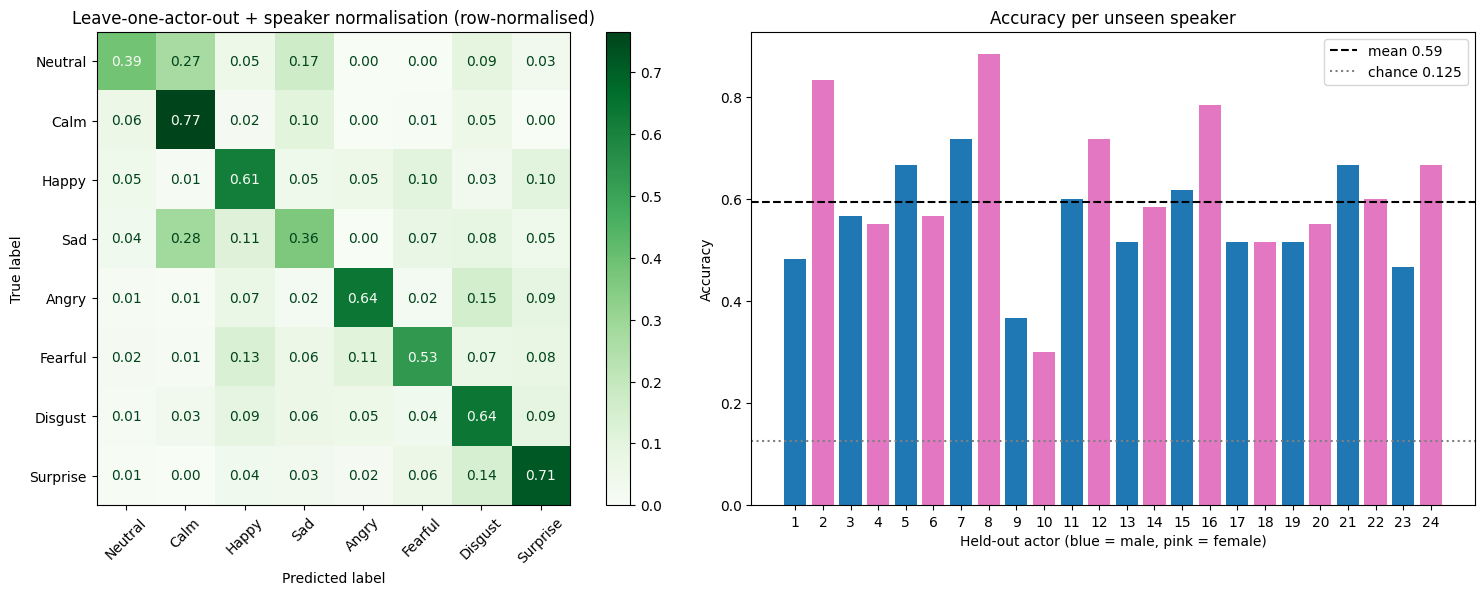

Best actor: 8 (0.88), worst: 10 (0.30)


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

emotion_dict = {1: 'Neutral', 2: 'Calm', 3: 'Happy', 4: 'Sad',
                5: 'Angry', 6: 'Fearful', 7: 'Disgust', 8: 'Surprise'}
labels_sorted = sorted(emotion_dict)

y_pred_loao = cross_val_predict(clone(pipeline), X_spk, y, cv=LeaveOneGroupOut(), groups=actors, n_jobs=-1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(
    y, y_pred_loao, labels=labels_sorted,
    display_labels=[emotion_dict[l] for l in labels_sorted],
    normalize='true', values_format='.2f', cmap='Greens', xticks_rotation=45, ax=axes[0])
axes[0].set_title('Leave-one-actor-out + speaker normalisation (row-normalised)')

per_actor = pd.Series(y_pred_loao == y).groupby(actors).mean()
colors = ['tab:blue' if a % 2 else 'tab:pink' for a in per_actor.index]
axes[1].bar(per_actor.index.astype(str), per_actor.values, color=colors)
axes[1].axhline(per_actor.mean(), color='black', linestyle='--', label=f"mean {per_actor.mean():.2f}")
axes[1].axhline(0.125, color='grey', linestyle=':', label='chance 0.125')
axes[1].set_xlabel('Held-out actor (blue = male, pink = female)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy per unseen speaker')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Best actor: {per_actor.idxmax()} ({per_actor.max():.2f}), worst: {per_actor.idxmin()} ({per_actor.min():.2f})")